Boxes and Twirl Notation

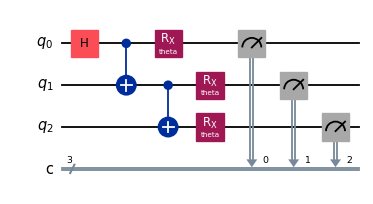

In [2]:
from qiskit.circuit import QuantumCircuit, Parameter


circuit = QuantumCircuit(3,3)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(1,2)
circuit.rx(Parameter('theta'), range(3))
circuit.measure(range(3),range(3))

circuit.draw('mpl', scale=0.65)

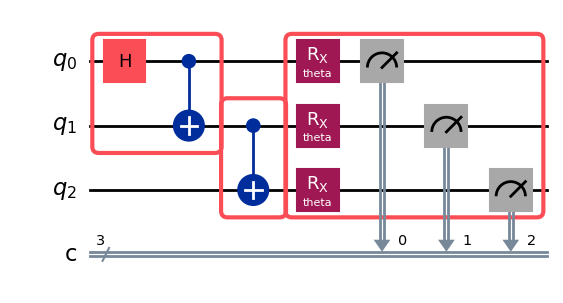

In [ ]:
from matplotlib.pyplot import box
from qiskit.circuit import BoxOp
from samplomatic import Twirl


boxed_circuit = QuantumCircuit(3,3)
with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.h(0)
    boxed_circuit.cx(0,1)
    

with boxed_circuit.box(annotations=[Twirl(decomposition="rzrx")]):
    boxed_circuit.cx(1,2)
    

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.rx(Parameter("theta"), range(3))
    boxed_circuit.measure(range(3), range(3))

boxed_circuit.draw('mpl')

In [4]:
for idx, instruction in enumerate(boxed_circuit):

    print(f"Annotations of box #{idx}: {instruction.operation.annotations}\n")

Annotations of box #0: [Twirl(group='pauli', dressing='left', decomposition='rzsx')]

Annotations of box #1: [Twirl(group='pauli', dressing='left', decomposition='rzrx')]

Annotations of box #2: [Twirl(group='pauli', dressing='left', decomposition='rzsx')]



In [5]:
from samplomatic import build
template_circuit, samplex = build(boxed_circuit)

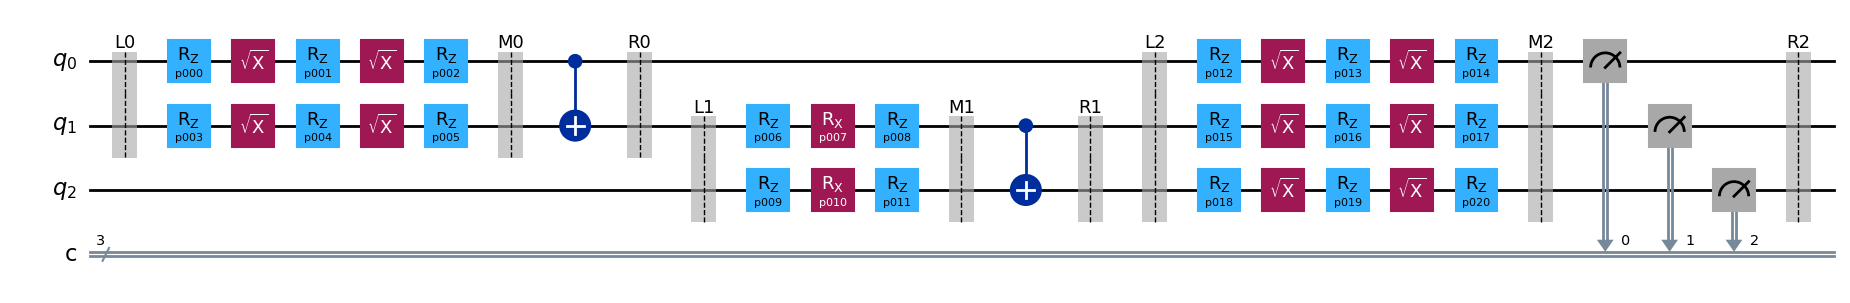

In [12]:
template_circuit.draw('mpl', fold=-1)

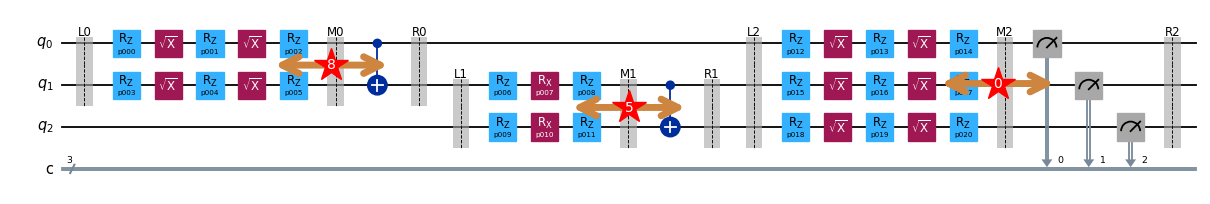

In [8]:
from IPython.display import display
from qiskit.visualization import circuit_drawer
from matplotlib.patches import FancyArrowPatch

fig = circuit_drawer(template_circuit, output="mpl", scale=0.65, fold=100)
ax = fig.gca()

pos = [(0.27, 0.7), (0.52, 0.47), (0.83, 0.6)]

for (x, y), text in zip(pos, ["8", "5", "0"]):
    ax.plot(x, y, marker="*", color="red", markersize=25, zorder=100, transform=ax.transAxes)
    ax.text(x, y, text, color="white", ha="center", va="center", fontsize=10, zorder=101, transform=ax.transAxes)


for idx, (x, y) in enumerate(pos):
    arrow = FancyArrowPatch(
        (x-0.05, y),
        (x+0.05, y),
        arrowstyle="<->",
        transform=ax.transAxes,
        zorder=99,
        mutation_scale=30,
        linewidth=5,
        color="peru",
    )
    ax.add_patch(arrow)

display(fig)


### The Samplex:
- Samplex encodes all the information required to generate randomized parameters for `template_circuit`.
- It represents the probability distribution for parameters in `template_circuit` and for the classical information required to post-process its outputs.

- The output of `samplex.sample` contain:

    - `parameter_values` to implement hadamard gates, rx gates and twirling gates. If N is the number of randomizations, then `parameter_values` = (N,21). Here, 21 is the number of parameters in the `template_circuit`.

    - `measurement_flips.c` to implement bit_flips that undo the effect of measurement twirling and recover the results. These comes in the form of an array of booleans of shape `(5,1,3)`, where `5` is the number of randomization and `3` is the number of measurements.

In [9]:
print(samplex)

Samplex(<19 nodes>)
  Inputs:
  - 'parameter_values' <float64[1]>: Input parameter values to use during sampling.

  Outputs:
    * 'measurement_flips.c' <bool['num_randomizations', 1, 3]>: Bit-flip corrections for
        measurement twirling.
    * 'parameter_values' <float32['num_randomizations', 21]>: Parameter values valid for an
        associated template circuit.



In [10]:
# specify the value of theta
samplex_input = {"parameter_values": [0.1]}

# use samplex.sample to sample 5 set of parameters
outputs = samplex.sample(samplex_input, num_randomizations=5)

# access the sampled values in a dictionary
parameter_values = outputs['parameter_values']
measurement_flips = outputs['measurement_flips.c']

In [13]:
print(f"Samplex outputs:")
print(outputs.describe())

Samplex outputs:
* 'measurement_flips.c' <bool['num_randomizations', 1, 3]>: Bit-flip corrections for measurement twirling.
* 'parameter_values' <float32['num_randomizations', 21]>: Parameter values valid for an associated template circuit.



In [14]:
print(f"Shape of 'parameter_values': {parameter_values.shape}.")
print(f"Shape of 'measurement_flips.c': {measurement_flips.shape}.\n") 

Shape of 'parameter_values': (5, 21).
Shape of 'measurement_flips.c': (5, 1, 3).



In [15]:
fig = samplex.draw()
fig.update_layout(width=900, height=250)
fig.show()
# fig.savefig('samplex.png')

### Inconsistent dressing

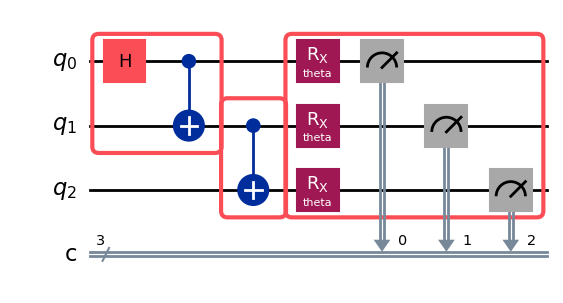

In [ ]:
boxed_circuit = QuantumCircuit(3,3)
with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.h(0)
    boxed_circuit.cx(0,1)
    

with boxed_circuit.box(annotations=[Twirl(dressing = "right")]):
    boxed_circuit.cx(1,2)
    

with boxed_circuit.box(annotations=[Twirl()]):
    boxed_circuit.rx(Parameter("theta"), range(3))
    boxed_circuit.measure(range(3), range(3))

boxed_circuit.draw('mpl')

## build process will raise error
# build(boxed_circuit)

In the above circuit, the build process will raise error as the central box has `Right` dressing. The virtual pauli emitted leftwards on q2 will not find any dressing that could implement it causing a build error. 